In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from scipy import stats
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from src.data_loader import load_data, remove_nulls,show_duplicates,fill_nulls
from src.analysis import calculate_ema,calculate_sma,calculate_rsi,identify_rsi_signals,calculate_macd,calculate_macd_last_2_years,calculate_bollinger_bands,calculate_volatility,calculate_max_drawdown,calculate_bollinger_bands_2years
from src.plot import plot_bollinger_bands,plot_volatility,plot_price_with_moving_averages,plot_price_with_bollinger_bands



[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\bemnet\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\bemnet\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# LOAD DATA

In [2]:
df = load_data("../data/raw/Data/GOOG.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322
1,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007
2,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329
3,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860
4,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852


#  DATA PREPARATION

In [3]:

# 1. Normalize timestamps (convert to timezone-naive)
# convert to datetime
df['Date'] = pd.to_datetime(df['Date'])

# make timezone-naive
df['Date'] = df['Date'].dt.tz_localize(None)

# verify
print(df['Date'].head())

# 2. Ensure columns are correctly typed
df = df.astype({'Open': 'float64', 'High': 'float64', 'Low': 'float64', 'Close': 'float64', 'Volume': 'float64'})

0   2009-01-02
1   2009-01-05
2   2009-01-06
3   2009-01-07
4   2009-01-08
Name: Date, dtype: datetime64[ns]


# HANDLE MISSING VALUES


In [4]:
df = fill_nulls(df)
df = remove_nulls(df)
df.head()

No missing values found.


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

No missing values found. All 3774 rows kept.


,Date,Close,High,Low,Open,Volume
0,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322.0
1,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007.0
2,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329.0
3,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860.0
4,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852.0


# Technical Indicators with TA-Lib

In [5]:
df = df.sort_values('Date')
df = calculate_sma(
    df,
    column='Close',
    windows=[20,50,100]
)

# calculate EMA
df = calculate_ema(
    df,
    column='Close',
    windows=[20,50,100]
)

# display results
print(df.tail(20))

           Date       Close        High         Low        Open      Volume  \
3754 2023-12-01  132.413849  132.592618  131.253773  132.413849  24268000.0   
3755 2023-12-04  129.742142  130.556560  128.520491  130.401630  24117100.0   
3756 2023-12-05  131.490189  132.632366  128.848264  129.483914  19235100.0   
3757 2023-12-06  130.536713  132.403940  130.417533  131.996723  16360600.0   
3758 2023-12-07  137.509003  139.048471  135.304090  135.671586  38419400.0   
3759 2023-12-08  135.711288  137.052119  134.648569  134.737954  23016100.0   
3760 2023-12-11  133.784485  133.873870  131.986789  132.910476  24502900.0   
3761 2023-12-12  132.731689  133.625566  131.927197  132.364209  26584000.0   
3762 2023-12-13  133.059433  133.863925  132.046361  133.630522  25414500.0   
3763 2023-12-14  132.294662  134.117197  130.169208  133.853999  29619100.0   
3764 2023-12-15  132.930344  133.913620  131.728576  132.016598  58594000.0   
3765 2023-12-18  136.257538  137.439452  132.860785 

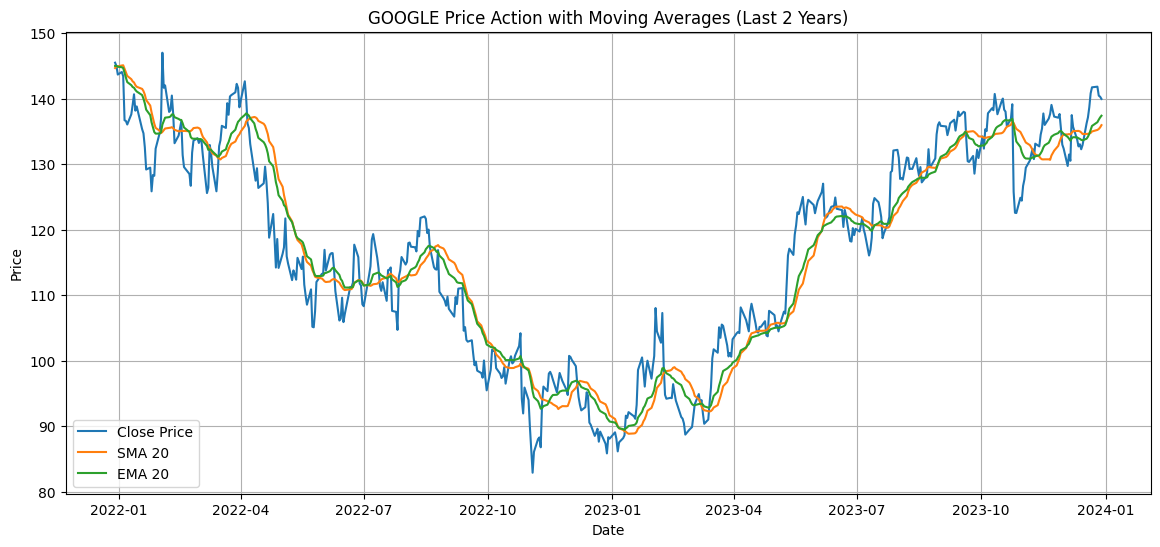

In [8]:
plot_price_with_moving_averages(
    df,
    ticker='GOOGLE'
)

### Moving Average Analysis Summary

- The stock showed a strong long-term upward trend, especially after 2019.
- SMA and EMA closely followed the closing price, confirming the overall market direction.
- EMA reacted more quickly to short-term price fluctuations, while SMA appeared smoother and lagged slightly behind price movements.
- Periods where moving averages moved sharply upward reflected strong bullish momentum and increased market activity.
- Higher volatility was observed between 2020 and 2023, with larger price swings and rapid trend changes.

### Relative Strength Index(RSI)

In [9]:
df = calculate_rsi(
    df,
    column='Close',
    period=14
)

In [10]:



df = identify_rsi_signals(df)

print(
    df[
        ['Date', 'Close', 'RSI', 'Overbought', 'Oversold']
    ].tail(20)
)

           Date       Close        RSI  Overbought  Oversold
3754 2023-12-01  132.413849  45.007044       False     False
3755 2023-12-04  129.742142  39.566938       False     False
3756 2023-12-05  131.490189  44.309941       False     False
3757 2023-12-06  130.536713  42.357188       False     False
3758 2023-12-07  137.509003  57.208225       False     False
3759 2023-12-08  135.711288  53.388852       False     False
3760 2023-12-11  133.784485  49.569011       False     False
3761 2023-12-12  132.731689  47.566445       False     False
3762 2023-12-13  133.059433  48.267122       False     False
3763 2023-12-14  132.294662  46.698937       False     False
3764 2023-12-15  132.930344  48.205282       False     False
3765 2023-12-18  136.257538  55.322365       False     False
3766 2023-12-19  137.161362  57.048922       False     False
3767 2023-12-20  138.710785  59.909189       False     False
3768 2023-12-21  140.836227  63.499976       False     False
3769 2023-12-22  141.750

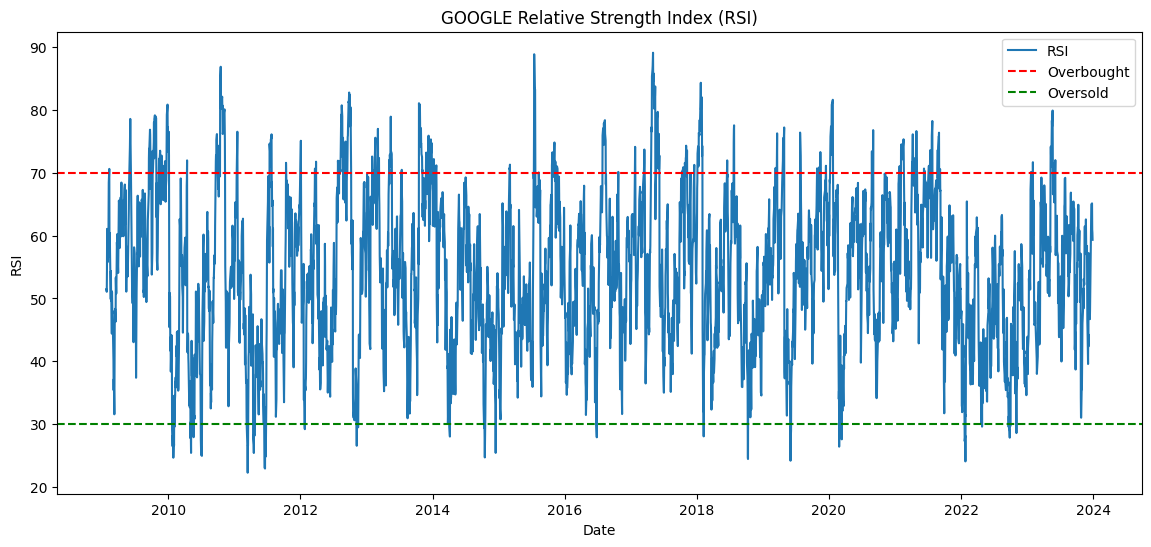

In [12]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['RSI'],
    label='RSI'
)

# overbought line
plt.axhline(
    70,
    color='red',
    linestyle='--',
    label='Overbought'
)

# oversold line
plt.axhline(
    30,
    color='green',
    linestyle='--',
    label='Oversold'
)

plt.xlabel("Date")
plt.ylabel("RSI")

plt.title("GOOGLE Relative Strength Index (RSI)")

plt.legend()

plt.show()

#### RSI Analysis Summary

- The RSI fluctuated frequently between overbought and oversold levels, indicating changing market momentum over time.
- Several periods crossed above the 70 threshold, suggesting temporary overbought conditions and potential price pullbacks.
- Multiple dips below the 30 threshold indicated oversold conditions, which may signal possible buying opportunities or price rebounds.
- Most RSI values remained within the neutral range (30–70), reflecting normal market trading behavior during much of the period.

### MACD (Moving Average Convergence Divergence)


#### MACD Analysis Summary

- The MACD showed several changes between upward and downward market momentum over time.
- Market movements became more volatile after 2020, with larger price swings and stronger trends.
- Positive histogram values indicated upward momentum, while negative values showed downward momentum.
- Crossovers between the MACD and signal line suggested possible trend changes and trading signals.

#### MACD For The Last 2 Years

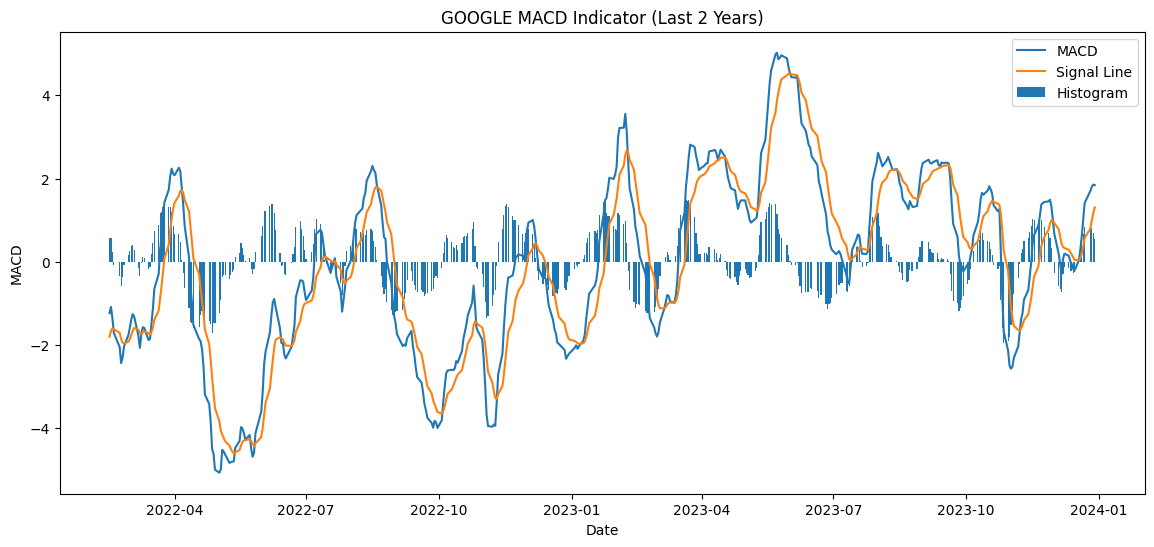

In [14]:
# calculate MACD for last 2 years
macd_df = calculate_macd_last_2_years(df)
plt.figure(figsize=(14,6))

# MACD line
plt.plot(
    macd_df['Date'],
    macd_df['MACD'],
    label='MACD'
)

# Signal line
plt.plot(
    macd_df['Date'],
    macd_df['MACD_Signal'],
    label='Signal Line'
)

# Histogram
plt.bar(
    macd_df['Date'],
    macd_df['MACD_Histogram'],
    label='Histogram'
)

plt.xlabel("Date")
plt.ylabel("MACD")

plt.title("GOOGLE MACD Indicator (Last 2 Years)")

plt.legend()

plt.show()

#### MACD Comparison Summary

- The 2-year MACD chart shows recent market movements more clearly than the full historical chart.
- Several crossings between the MACD and signal line show frequent changes between upward and downward trends.
- Strong upward momentum appeared during parts of 2022 and 2023, while some periods showed clear downward pressure.
- Compared to the previous chart, the shorter timeframe makes recent market trends and momentum changes easier to see.

# Financial Metrics

### Volatility
Measures how much stock prices fluctuate over time using the standard deviation of returns. Higher volatility indicates higher risk.

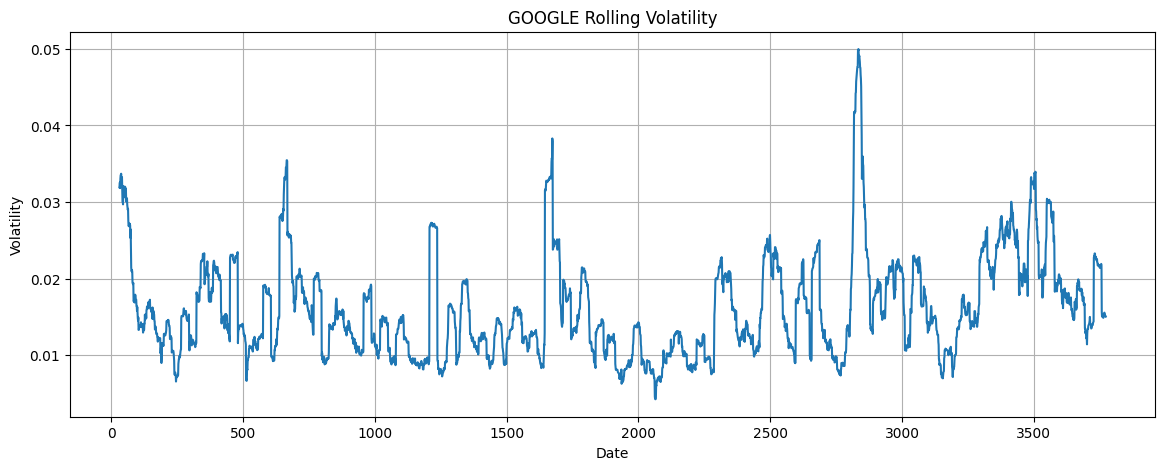

In [16]:
df = calculate_volatility(df)
plot_volatility(df, "GOOGLE")

#### Rolling Volatility Analysis

The rolling volatility analysis for AAPL over the last two years shows generally moderate market fluctuations, with volatility mostly ranging between 0.01 and 0.03. Several short-term spikes were observed, including a major peak above 0.06, indicating periods of increased market uncertainty and strong price movements. Toward the end of the period, volatility declined and stabilized, suggesting reduced market risk and calmer trading conditions.

### Bollinger Bands
A volatility indicator consisting of upper and lower bands around a moving average to identify overbought or oversold conditions.

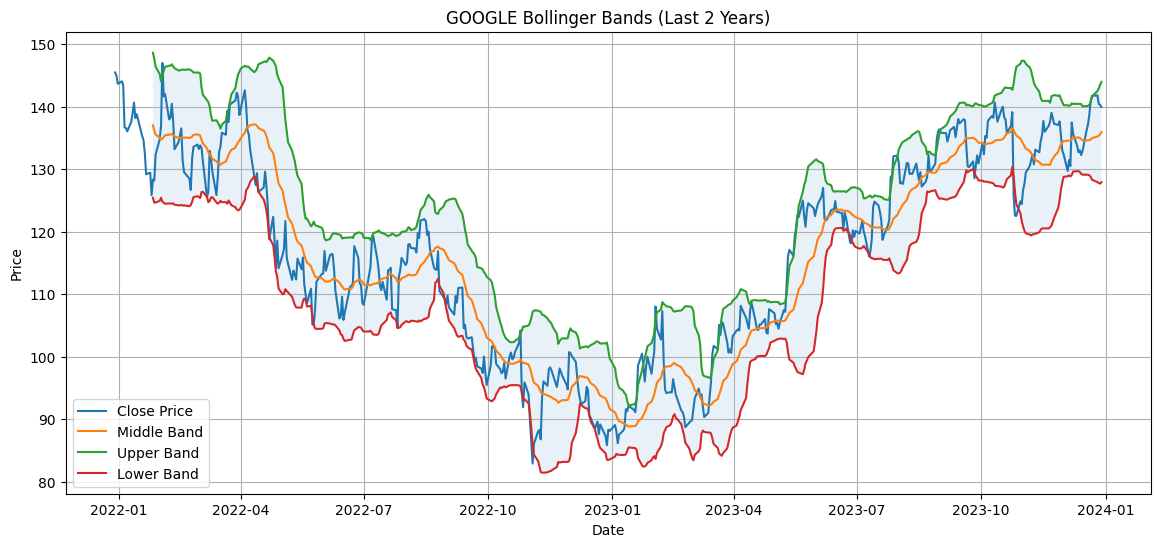

In [18]:
# Calculate Bollinger Bands
df_bollinger = calculate_bollinger_bands_2years(
    df,
    price_column='Close',
    date_column='Date',
    window=20,
    num_std=2
)
# Plot
plot_bollinger_bands(
    df_bollinger,
    ticker='GOOGLE',
    price_column='Close',
    date_column='Date',
    window=20
)

#### Bollinger Bands Analysis

The Bollinger Bands analysis for AAPL over the latest two years shows periods of both high and low market volatility. Wider bands indicate increased price fluctuations and higher market uncertainty, particularly during strong upward and downward price movements. Narrower bands reflect more stable trading periods with lower volatility. The stock price frequently moved near the upper band during bullish trends and near the lower band during market declines, highlighting changing market momentum throughout the period.